<a href="https://colab.research.google.com/github/Himanshu0518/Traffic-demand-prediction/blob/main/notebooks/traffic2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.5 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import KFold
from sklearn.metrics import r2_score

from catboost import CatBoostRegressor

In [3]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

print(train.shape)
print(test.shape)

(77299, 11)
(41778, 10)


In [4]:
train['RoadType'] = train['RoadType'].fillna(
    train['RoadType'].mode()[0]
)

test['RoadType'] = test['RoadType'].fillna(
    train['RoadType'].mode()[0]
)

train['Weather'] = train['Weather'].fillna(
    train['Weather'].mode()[0]
)

test['Weather'] = test['Weather'].fillna(
    train['Weather'].mode()[0]
)

train['Temperature'] = train['Temperature'].fillna(
    train['Temperature'].median()
)

test['Temperature'] = test['Temperature'].fillna(
    train['Temperature'].median()
)

In [5]:
train['timestamp'] = pd.to_datetime(
    train['timestamp'],
    format='%H:%M'
)

test['timestamp'] = pd.to_datetime(
    test['timestamp'],
    format='%H:%M'
)

train['hour'] = train['timestamp'].dt.hour
test['hour'] = test['timestamp'].dt.hour

In [6]:
road_map = {
    'Residential':1,
    'Street':2,
    'Highway':3
}

train['RoadType_enc'] = (
    train['RoadType']
    .map(road_map)
    .astype(int)
)

test['RoadType_enc'] = (
    test['RoadType']
    .map(road_map)
    .astype(int)
)

In [7]:
vehicle_map = {
    'Allowed':1,
    'Not Allowed':0
}

train['LargeVehicles'] = (
    train['LargeVehicles']
    .map(vehicle_map)
)

test['LargeVehicles'] = (
    test['LargeVehicles']
    .map(vehicle_map)
)

In [8]:
landmark_map = {
    'Yes':1,
    'No':0
}

train['Landmarks'] = (
    train['Landmarks']
    .map(landmark_map)
)

test['Landmarks'] = (
    test['Landmarks']
    .map(landmark_map)
)

In [9]:
train['road_lane'] = (
    train['RoadType_enc']
    *
    train['NumberofLanes']
)

test['road_lane'] = (
    test['RoadType_enc']
    *
    test['NumberofLanes']
)

In [10]:
train['road_vehicle'] = (
    train['RoadType_enc']
    *
    train['LargeVehicles']
)

test['road_vehicle'] = (
    test['RoadType_enc']
    *
    test['LargeVehicles']
)

In [11]:
geo_freq_map = train['geohash'].value_counts()

train['geo_freq'] = train['geohash'].map(
    geo_freq_map
)

test['geo_freq'] = (
    test['geohash']
    .map(geo_freq_map)
    .fillna(0)
)

In [12]:
train['geo_hour'] = (
    train['geohash']
    + "_"
    + train['hour'].astype(str)
)

test['geo_hour'] = (
    test['geohash']
    + "_"
    + test['hour'].astype(str)
)

In [13]:
train['road_hour'] = (
    train['RoadType_enc'].astype(str)
    + "_"
    + train['hour'].astype(str)
)

test['road_hour'] = (
    test['RoadType_enc'].astype(str)
    + "_"
    + test['hour'].astype(str)
)

In [14]:
train['geo_road'] = (
    train['geohash']
    + "_"
    + train['RoadType_enc'].astype(str)
)

test['geo_road'] = (
    test['geohash']
    + "_"
    + test['RoadType_enc'].astype(str)
)

In [15]:
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

global_mean = train['demand'].mean()

In [16]:
train['geo_target_kfold'] = np.nan

for tr_idx,val_idx in kf.split(train):

    tr = train.iloc[tr_idx]
    val = train.iloc[val_idx]

    means = tr.groupby(
        'geohash'
    )['demand'].mean()

    train.loc[
        val_idx,
        'geo_target_kfold'
    ] = val['geohash'].map(means)

train['geo_target_kfold'] = (
    train['geo_target_kfold']
    .fillna(global_mean)
)

In [17]:
train['geo_hour_target_kfold'] = np.nan

for tr_idx,val_idx in kf.split(train):

    tr = train.iloc[tr_idx]
    val = train.iloc[val_idx]

    means = tr.groupby(
        'geo_hour'
    )['demand'].mean()

    train.loc[
        val_idx,
        'geo_hour_target_kfold'
    ] = val['geo_hour'].map(means)

train['geo_hour_target_kfold'] = (
    train['geo_hour_target_kfold']
    .fillna(global_mean)
)

In [18]:
train['road_hour_target_kfold'] = np.nan

for tr_idx,val_idx in kf.split(train):

    tr = train.iloc[tr_idx]
    val = train.iloc[val_idx]

    means = tr.groupby(
        'road_hour'
    )['demand'].mean()

    train.loc[
        val_idx,
        'road_hour_target_kfold'
    ] = val['road_hour'].map(means)

train['road_hour_target_kfold'] = (
    train['road_hour_target_kfold']
    .fillna(global_mean)
)

In [19]:
train['geo_road_target_kfold'] = np.nan

for tr_idx,val_idx in kf.split(train):

    tr = train.iloc[tr_idx]
    val = train.iloc[val_idx]

    means = tr.groupby(
        'geo_road'
    )['demand'].mean()

    train.loc[
        val_idx,
        'geo_road_target_kfold'
    ] = val['geo_road'].map(means)

train['geo_road_target_kfold'] = (
    train['geo_road_target_kfold']
    .fillna(global_mean)
)

In [20]:
geo_mean = train.groupby(
    'geohash'
)['demand'].mean()

test['geo_target_kfold'] = (
    test['geohash']
    .map(geo_mean)
    .fillna(global_mean)
)

In [21]:
geo_hour_mean = train.groupby(
    'geo_hour'
)['demand'].mean()

test['geo_hour_target_kfold'] = (
    test['geo_hour']
    .map(geo_hour_mean)
    .fillna(global_mean)
)

In [22]:
road_hour_mean = train.groupby(
    'road_hour'
)['demand'].mean()

test['road_hour_target_kfold'] = (
    test['road_hour']
    .map(road_hour_mean)
    .fillna(global_mean)
)

In [23]:
geo_road_mean = train.groupby(
    'geo_road'
)['demand'].mean()

test['geo_road_target_kfold'] = (
    test['geo_road']
    .map(geo_road_mean)
    .fillna(global_mean)
)

In [24]:
print(
    test['road_hour_target_kfold']
    .eq(global_mean)
    .mean()
)

print(
    test['geo_road_target_kfold']
    .eq(global_mean)
    .mean()
)

0.0
0.02915410024414764


In [26]:
from catboost import CatBoostRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
import numpy as np

best_features = [
    'day',
    'hour',
    'RoadType_enc',
    'geo_freq',
    'road_lane',
    'road_vehicle',
    'geo_target_kfold',
    'geo_hour_target_kfold',
    'road_hour_target_kfold',
    'geo_road_target_kfold'
]

X = train[best_features]
y = train['demand']

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X), 1):

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    model = CatBoostRegressor(
        iterations=1500,
        learning_rate=0.03,
        depth=8,
        loss_function='RMSE',
        eval_metric='R2',
        random_seed=42,
        verbose=0
    )

    model.fit(
        X_train,
        y_train,
        eval_set=(X_val, y_val),
        early_stopping_rounds=200,
        use_best_model=True
    )

    preds = model.predict(X_val)

    score = r2_score(y_val, preds)

    scores.append(score)

    print(f"Fold {fold}: {score:.6f}")

print("\nMean CV R² =", np.mean(scores))
print("Std CV R² =", np.std(scores))

Fold 1: 0.955272
Fold 2: 0.953009
Fold 3: 0.956866
Fold 4: 0.952726
Fold 5: 0.958374

Mean CV R² = 0.9552495423937583
Std CV R² = 0.0021802152602378414


In [27]:
X = train[best_features]
y = train['demand']

final_model = CatBoostRegressor(
    iterations=1500,
    learning_rate=0.03,
    depth=8,
    loss_function='RMSE',
    eval_metric='R2',
    random_seed=42,
    verbose=200
)

final_model.fit(X, y)

0:	learn: 0.0532204	total: 28.9ms	remaining: 43.3s
200:	learn: 0.9558408	total: 3.14s	remaining: 20.3s
400:	learn: 0.9593799	total: 5.94s	remaining: 16.3s
600:	learn: 0.9617557	total: 8.79s	remaining: 13.1s
800:	learn: 0.9634312	total: 12.3s	remaining: 10.8s
1000:	learn: 0.9647137	total: 15.6s	remaining: 7.77s
1200:	learn: 0.9657892	total: 18.4s	remaining: 4.58s
1400:	learn: 0.9666708	total: 21.3s	remaining: 1.5s
1499:	learn: 0.9670966	total: 22.8s	remaining: 0us


CatBoostRegressor(depth=8, eval_metric='R2', iterations=1500, learning_rate=0.03, loss_function='RMSE', random_seed=42, verbose=200)

## Learning Curve

Let's plot the learning curve to understand how the model's performance changes with the amount of training data. This helps in identifying if the model is overfitting or underfitting.

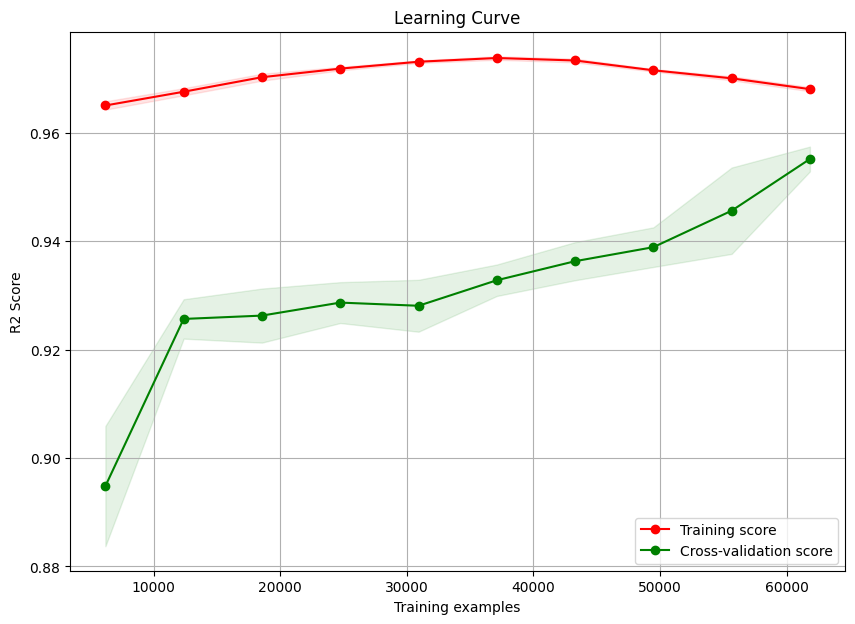

In [28]:
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    estimator=CatBoostRegressor(
        iterations=1500,
        learning_rate=0.03,
        depth=8,
        loss_function='RMSE',
        eval_metric='R2',
        random_seed=42,
        verbose=0
    ),
    X=X,
    y=y,
    cv=kf,
    scoring='r2',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    random_state=42
)

train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
val_scores_mean = np.mean(val_scores, axis=1)
val_scores_std = np.std(val_scores, axis=1)

plt.figure(figsize=(10, 7))
plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.1,
                 color="r")
plt.fill_between(train_sizes, val_scores_mean - val_scores_std,
                 val_scores_mean + val_scores_std, alpha=0.1,
                 color="g")
plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
         label="Training score")
plt.plot(train_sizes, val_scores_mean, 'o-', color="g",
         label="Cross-validation score")
plt.xlabel("Training examples")
plt.ylabel("R2 Score")
plt.title("Learning Curve")
plt.legend(loc="best")
plt.grid(True)
plt.show()

## Optuna Hyperparameter Tuning

Now, let's use Optuna to find the optimal hyperparameters for the CatBoostRegressor model. This will involve defining an objective function that Optuna will optimize.

In [29]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 31.7 MB/s eta 0:00:00


In [31]:
import optuna

def objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 100, 1000), # Reduced iterations for faster tuning
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'depth': trial.suggest_int('depth', 4, 8), # Reduced depth for faster tuning
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-4, 10.0, log=True),
        'random_seed': 42,
        'verbose': 0,
        'loss_function': 'RMSE',
        'eval_metric': 'R2',
        'early_stopping_rounds': 20 # Reduced for much faster tuning
    }

    model = CatBoostRegressor(**params)

    r2_scores = []
    for fold, (train_idx, val_idx) in enumerate(kf.split(X), 1):
        X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
        y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]

        model.fit(
            X_train_fold,
            y_train_fold,
            eval_set=(X_val_fold, y_val_fold),
            early_stopping_rounds=params['early_stopping_rounds'],
            use_best_model=True
        )
        preds = model.predict(X_val_fold)
        r2_scores.append(r2_score(y_val_fold, preds))

    return np.mean(r2_scores)

# Create an Optuna study and optimize it
study = optuna.create_study(direction='maximize', study_name='CatBoost R2 Optimization')
study.optimize(objective, n_trials=10) # Significantly reduced n_trials for quicker demonstration

print("Number of finished trials: ", len(study.trials))
print("Best trial:")
trial = study.best_trial

print("  Value: ", trial.value)
print("  Params: ")
for key, value in trial.params.items():
    print(f"    {key}: {value}")

[I 2026-06-03 04:33:58,069] A new study created in memory with name: CatBoost R2 Optimization
[I 2026-06-03 04:34:12,447] Trial 0 finished with value: 0.9552397948948549 and parameters: {'iterations': 387, 'learning_rate': 0.09489081546567017, 'depth': 8, 'l2_leaf_reg': 0.08493175049877012}. Best is trial 0 with value: 0.9552397948948549.
[I 2026-06-03 04:34:26,774] Trial 1 finished with value: 0.9543059881072431 and parameters: {'iterations': 748, 'learning_rate': 0.073628047229987, 'depth': 5, 'l2_leaf_reg': 2.378561922805203}. Best is trial 0 with value: 0.9552397948948549.
[I 2026-06-03 04:34:49,522] Trial 2 finished with value: 0.9537135230019956 and parameters: {'iterations': 919, 'learning_rate': 0.05540579988965029, 'depth': 4, 'l2_leaf_reg': 8.12155305356283}. Best is trial 0 with value: 0.9552397948948549.
[I 2026-06-03 04:34:57,618] Trial 3 finished with value: 0.943526790531734 and parameters: {'iterations': 133, 'learning_rate': 0.020458887421282324, 'depth': 7, 'l2_leaf_r

Number of finished trials:  10
Best trial:
  Value:  0.9552397948948549
  Params: 
    iterations: 387
    learning_rate: 0.09489081546567017
    depth: 8
    l2_leaf_reg: 0.08493175049877012


## KFold Cross-Validation with Optuna's Best Parameters

Let's evaluate the model using the best hyperparameters found by Optuna through KFold cross-validation.

In [32]:
best_params = study.best_trial.params

# Instantiate CatBoostRegressor with best parameters
model_optimized = CatBoostRegressor(
    iterations=best_params['iterations'],
    learning_rate=best_params['learning_rate'],
    depth=best_params['depth'],
    l2_leaf_reg=best_params['l2_leaf_reg'],
    loss_function='RMSE',
    eval_metric='R2',
    random_seed=42,
    verbose=0
)

optimized_scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X), 1):

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    model_optimized.fit(
        X_train,
        y_train,
        eval_set=(X_val, y_val),
        early_stopping_rounds=best_params.get('early_stopping_rounds', 50), # Use early_stopping_rounds from params if available
        use_best_model=True
    )

    preds = model_optimized.predict(X_val)

    score = r2_score(y_val, preds)

    optimized_scores.append(score)

    print(f"Fold {fold} (Optimized): {score:.6f}")

print("\nMean CV R² (Optimized) =", np.mean(optimized_scores))
print("Std CV R² (Optimized) =", np.std(optimized_scores))

Fold 1 (Optimized): 0.955232
Fold 2 (Optimized): 0.953672
Fold 3 (Optimized): 0.956621
Fold 4 (Optimized): 0.952591
Fold 5 (Optimized): 0.958365

Mean CV R² (Optimized) = 0.9552963994699877
Std CV R² (Optimized) = 0.0020559502733519083


## Learning Curve with Optuna's Best Parameters

Now, let's plot the learning curve again using the optimized hyperparameters to see the impact of tuning.

In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

train_sizes_optimized, train_scores_optimized, val_scores_optimized = learning_curve(
    estimator=CatBoostRegressor(
        iterations=best_params['iterations'],
        learning_rate=best_params['learning_rate'],
        depth=best_params['depth'],
        l2_leaf_reg=best_params['l2_leaf_reg'],
        loss_function='RMSE',
        eval_metric='R2',
        random_seed=42,
        verbose=0
    ),
    X=X,
    y=y,
    cv=kf,
    scoring='r2',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    random_state=42
)

train_scores_mean_optimized = np.mean(train_scores_optimized, axis=1)
train_scores_std_optimized = np.std(train_scores_optimized, axis=1)
val_scores_mean_optimized = np.mean(val_scores_optimized, axis=1)
val_scores_std_optimized = np.std(val_scores_optimized, axis=1)

plt.figure(figsize=(10, 7))
plt.fill_between(train_sizes_optimized, train_scores_mean_optimized - train_scores_std_optimized,
                 train_scores_mean_optimized + train_scores_std_optimized, alpha=0.1,
                 color="r")
plt.fill_between(train_sizes_optimized, val_scores_mean_optimized - val_scores_std_optimized,
                 val_scores_mean_optimized + val_scores_std_optimized, alpha=0.1,
                 color="g")
plt.plot(train_sizes_optimized, train_scores_mean_optimized, 'o-', color="r",
         label="Training score (Optimized)")
plt.plot(train_sizes_optimized, val_scores_mean_optimized, 'o-', color="g",
         label="Cross-validation score (Optimized)")
plt.xlabel("Training examples")
plt.ylabel("R2 Score")
plt.title("Learning Curve with Optimized Hyperparameters")
plt.legend(loc="best")
plt.grid(True)
plt.show()

In [ ]:
X_test = test[best_features]

predictions = final_model.predict(X_test)

submission = pd.DataFrame({
    'Index': test['Index'],
    'demand': predictions
})

submission['demand'] = submission['demand'].clip(lower=0)

submission.to_csv(
    'submission_fixed.csv',
    index=False
)

In [ ]:
submission.head()
print(submission.shape)
print(submission.isnull().sum())

(41778, 2)
Index     0
demand    0
dtype: int64


In [ ]:
old = pd.read_csv("submission_final.csv")
new = pd.read_csv("submission_fixed.csv")

print("OLD")
print(old['demand'].describe())

print("\nNEW")
print(new['demand'].describe())

OLD
count    41778.000000
mean         0.120978
std          0.103924
min          0.013671
25%          0.041654
50%          0.086534
75%          0.157630
max          0.598103
Name: demand, dtype: float64

NEW
count    41778.000000
mean         0.126900
std          0.158217
min          0.001257
25%          0.032372
50%          0.067775
75%          0.137638
max          0.948499
Name: demand, dtype: float64


In [ ]:
diff = abs(new['demand'] - old['demand'])

print("Mean Difference:", diff.mean())
print("Max Difference:", diff.max())
print("Rows Changed:", (diff > 1e-6).sum())

Mean Difference: 0.03032630940368146
Max Difference: 0.4581368510173715
Rows Changed: 41778


In [ ]:
corr = old['demand'].corr(new['demand'])

print("Correlation:", corr)

Correlation: 0.9704066763929239


In [ ]:
comparison = pd.DataFrame({
    'Index': old['Index'],
    'old': old['demand'],
    'new': new['demand']
})

comparison['diff'] = abs(
    comparison['new'] - comparison['old']
)

comparison.sort_values(
    'diff',
    ascending=False
).head(20)

,Index,old,new,diff
39163,39163,0.418285,0.876422,0.458137
23438,23438,0.447343,0.892799,0.445456
21668,21668,0.447343,0.892799,0.445456
27058,27058,0.451486,0.890499,0.439013
26150,26150,0.451486,0.890499,0.439013
25251,25251,0.451486,0.890499,0.439013
34182,34182,0.458831,0.892670,0.433840
28719,28719,0.447514,0.873803,0.426289
34899,34899,0.451795,0.877936,0.426141
32277,32277,0.451795,0.877936,0.426141


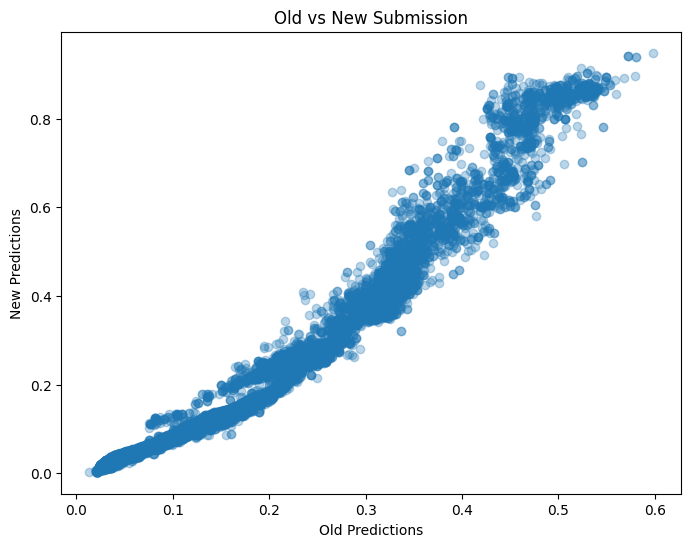

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(
    old['demand'],
    new['demand'],
    alpha=0.3
)

plt.xlabel("Old Predictions")
plt.ylabel("New Predictions")
plt.title("Old vs New Submission")
plt.show()

In [ ]:
corr = old['demand'].corr(new['demand'])
print(corr)

0.9704066763929239


In [ ]:
diff = abs(new['demand'] - old['demand'])
print(diff.mean())

0.03032630940368146


In [ ]:
old = pd.read_csv("submission_final.csv")
new = pd.read_csv("submission_fixed.csv")

comparison = pd.DataFrame({
    "old": old["demand"],
    "new": new["demand"]
})

comparison["diff"] = abs(
    comparison["new"] - comparison["old"]
)

print(comparison["diff"].describe())

count    41778.000000
mean         0.030326
std          0.055102
min          0.000002
25%          0.010846
50%          0.016069
75%          0.022493
max          0.458137
Name: diff, dtype: float64
